In [4]:
# Nettoyage complet
print("Nettoyage...")
%reset -f
%whos

Nettoyage...
Interactive namespace is empty.


In [5]:
import numpy.random as rd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from sqlalchemy import text
import sqlalchemy
import gc
import pyodbc
from datetime import datetime
from pandas import NaT
import math
from scipy.stats import expon
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderUnavailable
import time
from scipy.stats import gaussian_kde
from sklearn.neighbors import KernelDensity

In [6]:
# Connexion pyodbc à SQL Server

conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=172.16.11.34;"
    "DATABASE=LogiProDev;"
    "UID=quentin;"
    "PWD={Barbidur1;SQL}"
)

conn = pyodbc.connect(conn_str)
cursor = conn.cursor()

In [7]:
requete_duree_de_vie_negos = """
-- Requête qui permettra de trouver la distribution de la durée de vie empirique des négociateurs
-- ainsi que le processus suivi par leur date d'arrivée sur le marché.
-- Le groupe dans lequel ils arrivent, on s'en fiche comme la simulation doit se faire à l'échelle globale
-- A la limite, peut-être le faire entrer en jeu plus tard pcq le groupe d'appartenance peut avoir
-- une influence sur la durée de vie du négociateur

SELECT
    negociateur_id,
    neg_nom,
    neg_prenom,
    neg_date_creation,
    neg_date_archive,
    neg_actif
FROM dbo.t_negociateur
"""

In [8]:
duree_de_vie_negos = pd.read_sql_query(requete_duree_de_vie_negos, conn)
print(duree_de_vie_negos.columns)

Index(['negociateur_id', 'neg_nom', 'neg_prenom', 'neg_date_creation',
       'neg_date_archive', 'neg_actif'],
      dtype='object')


C:\Users\quent\AppData\Local\Temp\ipykernel_2744\179210131.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  duree_de_vie_negos = pd.read_sql_query(requete_duree_de_vie_negos, conn)


In [9]:
conn.commit()
cursor.close()
conn.close()

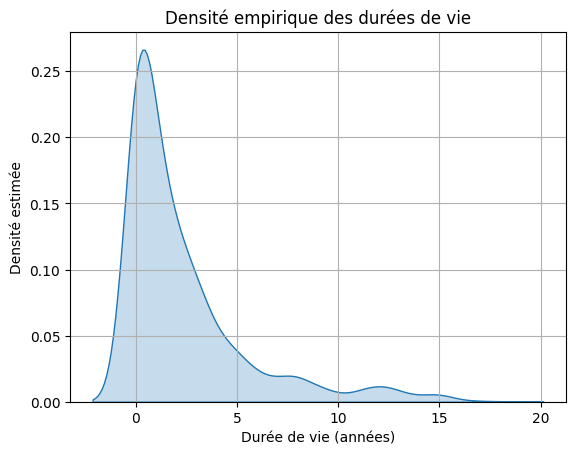

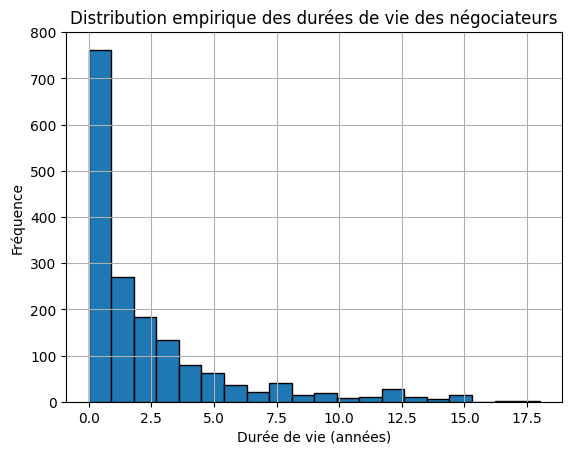

Min : 0.0027378507871321013
Max : 18.0
Moyenne : 2.338368419591326
Médiane : 1.1800136892539357
Écart-type : 3.1586075774899034


In [10]:
duree_de_vie_negos["duree_de_vie"] = duree_de_vie_negos["neg_date_creation"] - duree_de_vie_negos["neg_date_archive"]

liste_duree_de_vie_negos = duree_de_vie_negos["duree_de_vie"].tolist()
liste_duree_de_vie_negos = [x for x in liste_duree_de_vie_negos if x is not NaT]
liste_duree_de_vie_negos = [x for x in liste_duree_de_vie_negos if pd.notna(x) and x != pd.Timedelta(0)]
liste_duree_de_vie_negos = [x.days / 365.25 for x in liste_duree_de_vie_negos]
liste_duree_de_vie_negos = [np.abs(x) for x in liste_duree_de_vie_negos]
liste_duree_de_vie_negos = [x if x < 18 else 18 for x in liste_duree_de_vie_negos]

sns.kdeplot(liste_duree_de_vie_negos, fill=True)
plt.xlabel("Durée de vie (années)")
plt.ylabel("Densité estimée")
plt.title("Densité empirique des durées de vie")
plt.grid(True)
plt.show()

plt.hist(liste_duree_de_vie_negos, bins=20, edgecolor='black')
plt.xlabel("Durée de vie (années)")
plt.ylabel("Fréquence")
plt.title("Distribution empirique des durées de vie des négociateurs")
plt.grid(True)
plt.show()

valeurs = np.array(liste_duree_de_vie_negos)

print("Min :", np.min(valeurs))
print("Max :", np.max(valeurs))
print("Moyenne :", np.mean(valeurs))
print("Médiane :", np.median(valeurs))
print("Écart-type :", np.std(valeurs))

In [11]:
# On supprime ces datasets qui ne pourront donc pas servir

del liste_duree_de_vie_negos
del duree_de_vie_negos
gc.collect()

5433

**Problème : l'échantillon dont on dispose dans la BDD ne représente que le temps que les négociateurs restent inscrits sur LogiPro... En réalité, ce serait très étonnant qu'ils ne restent négociateurs pour la grande majorité qu'un an...**

Aucune étude existante ne donne une distribution de l'ancienneté des négociateurs avant de partir à la retraire ou de changer de métier. 

On n'aura donc aucun moyen de vérifier si les résultats du modèle en termes de longévité des négociateurs dans leur métier représentent bien la réalité. 

In [12]:
print(f"{sum(len(cell.splitlines()) for cell in get_ipython().user_ns['In'][1:] if cell)} lignes")

135 lignes
